# Data

In [1]:
import numpy as np
import pandas  as pd
import os
from IPython.display import clear_output
import pygad
from classes import MACDBacktester, backtest

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src')
from utils.utils import CreateTimeFrames

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\data')
#os.getcwd()

df = pd.read_csv('ETHUSD_2023_2024.csv',
                  index_col = 'Gmt time')
df.index = pd.to_datetime(df.index, format='%d.%m.%Y %H:%M:%S.%f', errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\genetic')

price_column = 'close'
date_split = "2024-10-1"
tf = '1h'

timeframes = ['1min','5min','15min', '30min','1h', '4h','1d','1w','1m']
df = CreateTimeFrames(df,timeframes)

working_dataset = df[tf]

working_dataset = working_dataset.iloc[-4050:,:]

train_end_index = int(len(working_dataset)*0.6)
TRAIN_END_DATE = working_dataset.index[train_end_index]

val_end_index = int(len(working_dataset)*0.7)
VAL_END_DATE = working_dataset.index[val_end_index]

df_train = working_dataset.loc[:TRAIN_END_DATE]
df_train = df_train.drop(index=df_train.index[-1])


val_data = working_dataset.loc[TRAIN_END_DATE:VAL_END_DATE]
val_data = val_data.drop(index = val_data.index[-1])

df_test = working_dataset.loc[VAL_END_DATE:]

assert len(df_train)+len(val_data)+len(df_test)== len(working_dataset), "Some data are missed."


signal_price = 'smoothed_data'
real_price = 'close'

clear_output()


# Algorithm


## MACD_GA class

In [2]:
import pygad
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

# Suppress specific warnings (UserWarnings in this case)
warnings.filterwarnings("ignore", category=UserWarning)

class MACD_GA:
    def __init__(self, df_train, fast_range=(1, 50), slow_range=(2, 50), signal_range=(2, 30),\
                  generations=120, population=50, mating_parents=25, real_price='close', signal_price = 'close' ):
        """"
        Find the best parameters for MACD with GA that has the best tuning.

        :param df_train: Dataframe containing dataset with or without smoothing column.
        :param fast_range: Tuple contains fast ema period.
        :param slow_range: Tuple contains slow ema period.
        :param signal_line: Tuple contains signal line period.
        :param generations: Integer contains the number generation in GA.
        :param population: Integer contains the number of solution in each generation.
        :param mating_parents: Integer contains the number of parents after choosing.
        :param real_price: Defualt is 'close' and is suitable for buy and sell.
        :param signal_price: Defualt is 'close' and is suitable for generation buy and sell signals.

        """
        self.df_train = df_train
        self.fast_range = fast_range
        self.slow_range = slow_range
        self.signal_range = signal_range
        self.generations = generations
        self.population = population
        self.mating_parents = mating_parents
        self.ga_instance = None
        self.best_solution = None
        self.real_price = real_price
        self.signal_price = signal_price


    def macd(self, data, fast, slow, signal):
        data['ema_fast'] = data[self.signal_price].ewm(span=fast, min_periods=1, adjust=False).mean()
        data['ema_slow'] = data[self.signal_price].ewm(span=slow, min_periods=1, adjust=False).mean()
        data['macd_line'] = data['ema_fast'] - data['ema_slow']
        data['signal_line'] = data['macd_line'].ewm(span=signal, adjust=False).mean()
        return data

    @staticmethod
    def backtest(data):
        buy_signals = (data['macd_line'] > data['signal_line']) & (data['macd_line'].shift(1) <= data['signal_line'].shift(1))
        sell_signals = (data['macd_line'] < data['signal_line']) & (data['macd_line'].shift(1) >= data['signal_line'].shift(1))

        positions = pd.Series(index=data.index, data=np.nan)
        positions[buy_signals] = 1
        positions[sell_signals] = 0
        positions.ffill(inplace=True)
        positions.fillna(0, inplace=True)

        data['Strategy'] = positions.shift(1) * (data['close'].pct_change())
        return data['Strategy'].cumsum().iloc[-1]

    def fitness_function(self, ga_instance, solution, solution_idx):
        ema_fast, ema_slow, signal = int(solution[0]), int(solution[1]), int(solution[2])
        if ema_fast >= ema_slow - 1:
            return -np.inf
        if ema_fast < 1 or ema_slow < ema_fast + 1 or signal < 1:
            return -np.inf
        temp_data = self.macd(self.df_train.copy(), ema_fast, ema_slow, signal)
        profit = self.backtest(temp_data)
        return profit

    def run_ga(self):
        # Initialize the GA instance
        self.ga_instance = pygad.GA(
            num_generations=self.generations,
            sol_per_pop=self.population,
            num_parents_mating=self.mating_parents,
            fitness_func=self.fitness_function,
            crossover_type="two_points",
            crossover_probability=0.8,
            num_genes=3,
            init_range_low=[self.fast_range[0], self.slow_range[0], self.signal_range[0]],
            init_range_high=[self.fast_range[1], self.slow_range[1], self.signal_range[1]],
            mutation_percent_genes=50,
            gene_type=int,
            save_solutions=True
        )
        # Run the GA
        self.ga_instance.run()
        # Save the best solution
        self.best_solution = self.ga_instance.best_solution()

    def get_best_parameters(self):
        if self.best_solution is None:
            return None
        solution, fitness, _ = self.best_solution
        return {
            "Fast EMA": int(solution[0]),
            "Slow EMA": int(solution[1]),
            "Signal Line": int(solution[2]),
            "Net Profit": fitness
        }

    def plot_results(self):
        if self.ga_instance:
            self.ga_instance.plot_fitness(title="Fitness Evolution")
            # self.ga_instance.plot_fitness()
            self.ga_instance.plot_genes(title="Fast, Slow, Signal")
            self.ga_instance.plot_new_solution_rate(title="New Solution Rate Evolution")

## EM-KF class

In [3]:
class KalmanFilterEM:
    def __init__(self, data, price_column, max_iter=100, tol=1e-3):
        """
        Initialize the Kalman Filter with EM algorithm class.
        
        :param data: DataFrame containing stock price data.
        :param price_column: The column name containing the price data.
        :param max_iter: Maximum number of iterations for the EM algorithm (default=100).
        :param tol: Convergence tolerance for the EM algorithm (default=1e-3).
        """
        self.data = data
        self.price_column = price_column
        self.max_iter = max_iter
        self.tol = tol
        
        self.price_data = self.data[self.price_column].values
        self.N = len(self.price_data)
        
        # Initialize Q (process noise variance) and R (measurement noise variance)
        self.Q = 1.0  # Initial guess for process noise variance
        self.R = 1.0  # Initial guess for measurement noise variance

    def kalman_filter(self):
        """
        Perform the forward pass of the Kalman filter.
        Returns the filtered state estimates and error covariances.
        """
        x_est = np.zeros(self.N)  # Estimated states
        P_est = np.zeros(self.N)  # Error covariances
        
        # Initial guesses for the first point
        x_est[0] = self.price_data[0]  # Initial state
        P_est[0] = 1.0  # Initial covariance

        # Kalman filtering process
        for t in range(1, self.N):
            # Prediction
            x_pred = x_est[t-1]  # Predict the next state
            P_pred = P_est[t-1] + self.Q  # Predict the error covariance
            
            # Kalman gain
            K = P_pred / (P_pred + self.R)
            
            # Update
            x_est[t] = x_pred + K * (self.price_data[t] - x_pred)
            P_est[t] = (1 - K) * P_pred
        
        return x_est, P_est

    def kalman_smoother(self, x_est, P_est):
        """
        Perform the backward pass (smoother) to refine state estimates.
        Returns the smoothed state estimates.
        """
        x_smooth = np.copy(x_est)  # Initialize smoothed estimates
        P_smooth = np.copy(P_est)  # Initialize smoothed error covariances
        
        for t in range(self.N-2, -1, -1):
            # Smoothing gain
            C = P_est[t] / (P_est[t] + self.Q)
            
            # Update smoothed estimates
            x_smooth[t] = x_est[t] + C * (x_smooth[t+1] - x_est[t])
            P_smooth[t] = P_est[t] + C * (P_smooth[t+1] - P_est[t])
        
        return x_smooth, P_smooth

    def optimize_em(self):
        """
        Optimize Q and R using the EM algorithm.
        """
        prev_log_likelihood = -np.inf
        
        for iteration in range(self.max_iter):
            # E-step: Run Kalman filter and smoother
            x_est, P_est = self.kalman_filter()  # Forward pass (filter)
            x_smooth, P_smooth = self.kalman_smoother(x_est, P_est)  # Backward pass (smoother)
            
            # M-step: Update Q and R
            # Process noise variance (Q) update
            Q_new = np.sum((x_smooth[1:] - x_smooth[:-1])**2 + P_smooth[1:]) / (self.N - 1)
            
            # Measurement noise variance (R) update
            R_new = np.sum((self.price_data - x_smooth)**2 + P_smooth) / self.N
            
            # Check for convergence (based on log-likelihood)
            log_likelihood = -0.5 * np.sum(np.log(2 * np.pi * (P_smooth + self.R)) + ((self.price_data - x_smooth)**2) / (P_smooth + self.R))
            if np.abs(log_likelihood - prev_log_likelihood) < self.tol:
                print(f'Converged after {iteration+1} iterations.')
                break
            
            # Update Q, R, and log-likelihood
            self.Q = Q_new
            self.R = R_new
            prev_log_likelihood = log_likelihood
            
        print(f"Final Q: {self.Q}, Final R: {self.R}")
        return self.Q, self.R

    def get_smoothed_data(self):
        """
        Get the smoothed data using the optimized Q and R.
        """
        x_est, P_est = self.kalman_filter()
        x_smooth, P_smooth = self.kalman_smoother(x_est, P_est)
        return x_smooth

    def plot_results(self, start, end):
        """
        Plot the original price and Kalman-filtered smoothed data.
        """
        smoothed_data = self.get_smoothed_data()  # Get smoothed data with optimized Q and R
        
        plt.figure(figsize=(12, 6))
        plt.plot(self.data.index[start: end], self.price_data[start: end], label='Original Price', color='blue')
        plt.plot(self.data.index[start: end], smoothed_data[start: end], label='Smoothed Data (Kalman Filter)', color='green')
        plt.legend()
        plt.title('Original Price vs. Kalman Filter Smoothed Price')
        plt.show()

## run MACD_GA and EM-KF

In [4]:
kf_em = KalmanFilterEM(df_train, price_column='close', max_iter=1000, tol=0.0001)

# Optimize Q and R using the EM algorithm
kf_em.optimize_em()

# Get smoothed data
smoothed_data = kf_em.get_smoothed_data()

df_train['smoothed_data'] = smoothed_data

Converged after 64 iterations.
Final Q: 248.7607351647429, Final R: 163.91522269054477


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Best Parameters: {'Fast EMA': 1, 'Slow EMA': 45, 'Signal Line': 2, 'Net Profit': 1.2323607391552618}


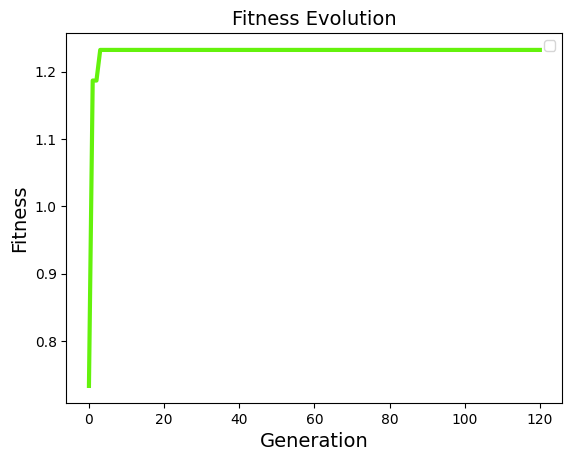

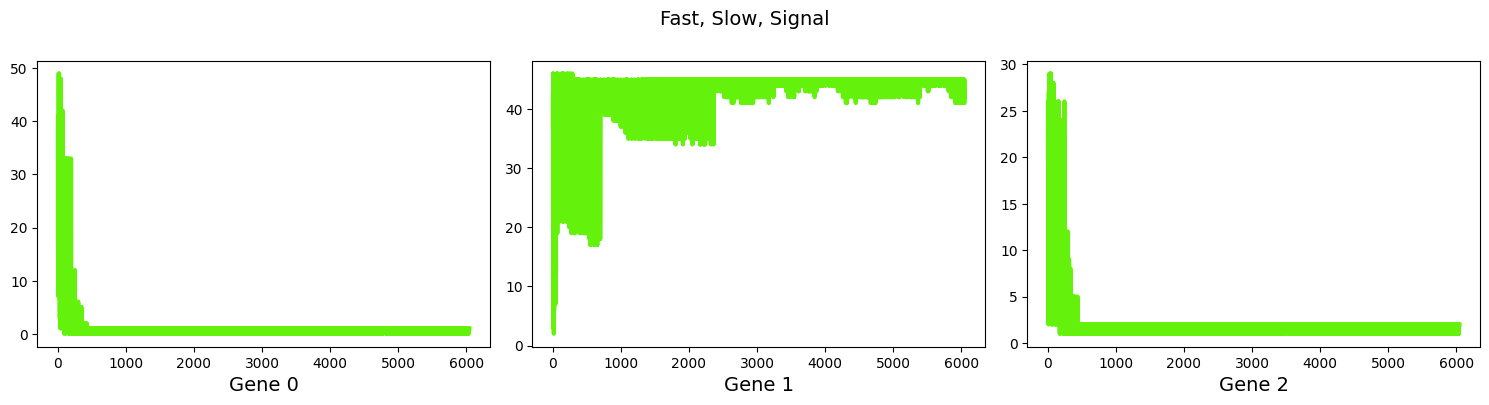

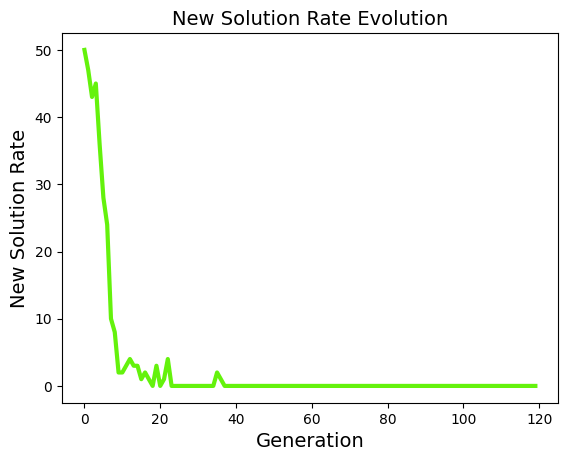

In [5]:
# Assuming you have a DataFrame `df_train` with 'close' prices
optimizer = MACD_GA(df_train=df_train, signal_price=signal_price)

# Run the genetic algorithm
optimizer.run_ga()

# Get the best parameters
best_params = optimizer.get_best_parameters()
print("Best Parameters:", best_params)

# Plot the results
optimizer.plot_results()

# Test

## Backtester class

In [6]:
class MACDBacktester:
    def __init__(self, data, fast_ema, slow_ema, signal_line, signal_price = 'close', real_price = 'close',
                  sell_fee = 0.115, buy_fee = 0.115, initial_capital = 100):
        """"
        It works as a trade andlyzer with an specific amount of money and trading cost.

        :param data: Dataframe contains different features
        :param fast_ema: Integer
        :param slow_ema: Ineger
        :param signal_line: Integer
        :param signal_price: for producing buy and sell signals(defualt:'close')
        :param real_price: for trading(defualt:'close')
        :param sell_fee: Float contains sell trading cost(defulat=0.115). Nobitex maker trading cost is 0.1 and taker is 0.13.
        :param buy_fee: Float contains buy trading cost(defulat=0.115). Nobitex
        :param initial_capital: Integer contains initial money to start.

        """
        self.data = data.copy()
        self.fast_ema = fast_ema
        self.slow_ema = slow_ema
        self.signal_line = signal_line
        self.signal_price = signal_price
        self.real_price = real_price
        self.sell_fee_percent = sell_fee / 100
        self.buy_fee_percent = buy_fee / 100
        self.initial_capital = initial_capital
        self.trades = []
        self.data['positions'] = 0
        
    def calculate_macd(self):
        self.data['fast_ema'] = self.data[self.signal_price].ewm(span = self.fast_ema, adjust = False).mean()
        self.data['slow_ema'] = self.data[self.signal_price].ewm(span = self.slow_ema, adjust = False).mean()
        self.data['macd_line'] = self.data['fast_ema'] - self.data['slow_ema']
        self.data['signal_line'] = self.data['macd_line'].ewm(span = self.signal_line, adjust = False).mean()


    def generate_signals(self):
        """
        Generates trading signals based on MACD crossover.
        """
        threshold = 0.1
        self.data['signal'] = 0
        self.data['signal'] = np.where((self.data['macd_line'] - self.data['signal_line']) > threshold, 1, 0) # Buy signal
        self.data['signal'] = np.where((self.data['macd_line'] - self.data['signal_line']) < -threshold, 0, self.data['signal']) # Sell signal
        # Generation the position by shifting the signals
        #self.data['positions'] = self.data['signal'].shift(1).fillna(0)
        self.data['positions'] = self.data['signal']
        return self.data

    def backtest_strategy(self):
        """
        Backtests the strategy and calculates performance metrics.
        """
        self.data['price'] = self.data[self.real_price]
        self.data['positions'] = self.data['positions'].astype(int)
        self.data['positions_diff'] = self.data['positions'].diff()
        self.data['positions_diff'].fillna(0)

        # Initialize cash and holdings
        self.data['cash'] = self.initial_capital
        self.data['holdings'] = 0.0
        self.data['total'] = self.initial_capital


        # Variable to keep track of cash, holdings, trades
        cash = self.initial_capital
        holdings = 0.0
        position = 0  # Current position (number of shares)
        buy_price = 0.0
        win_count = 0  # Win rate calculation
        total_trades = 0

        for idx, row in self.data.iterrows():
            position_change = row['positions_diff']
            price = row['price']
            if position_change == 1: # Long position
                # With regard to the randomness of market, I can decide how much of cash should spend for trading.
                shares_to_buy = round(cash/(price),8)
                shares_to_buy = shares_to_buy * (1-self.buy_fee_percent)

                if shares_to_buy > 0.00002:
                    buy_price = round((cash/shares_to_buy),8) 
                    total_cost = round(shares_to_buy * buy_price, 8)
                    cash -= total_cost
                    holdings += shares_to_buy * price
                    position += shares_to_buy


            elif position_change ==-1 and position > 0: # position is the number of shares.
                # Exit the long position
                sell_price = price * (1-self.sell_fee_percent)
                total_proceeds = position * sell_price
                cash += total_proceeds
                holdings -= position * sell_price
                # Calculate trade return
                trade_return = (sell_price - buy_price)/buy_price * 100
                self.trades.append(trade_return)
                position = 0
                total_trades +=1 # Win rate calculation
                if trade_return>0:
                    win_count +=1
            else:
                # Hold position
                holdings = position * price


            total = cash + holdings
            self.data.at[idx, 'cash'] = float(cash)
            self.data.at[idx, 'holdings'] = holdings
            self.data.at[idx, 'total'] = float(total)

        if position > 0 :
            
            price = self.data.iloc[-1]['price']
            sell_price = price * (1-self.sell_fee_percent)
            total_proceeds = position * sell_price
            cash += total_proceeds
            # Calculate trade return
            trade_return = (sell_price - buy_price) / buy_price * 100
            self.trades.append(trade_return)
            position = 0
            total_trades +=1 # Win rate calculation
            if trade_return>0:
                win_count +=1
            total = cash + holdings
            self.data.at[self.data.index[-1], 'cash'] = cash
            self.data.at[self.data.index[-1], 'holdings'] = holdings
            self.data.at[self.data.index[-1], 'total'] = total

        self.results = self.data[['cash', 'holdings', 'total']]
        self.results = self.data[['cash', 'holdings', 'total']]

        self.win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0
        return self.data

    def get_performance_metrics(self):
        """
        Calculates and returns performance metrics.
        """
        if self.results is None:
            print("Please run backtest_strategy() before calculating performance metrics.")
            return None

        total_return = (self.results['total'].iloc[-1] - self.initial_capital) / self.initial_capital * 100
        returns = self.results['total'].pct_change().fillna(0)
        annualized_return = ((1 + returns.mean()) ** 252 - 1) * 100  # Assuming daily returns
        annualized_volatility = returns.std() * np.sqrt(252) * 100
        sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() != 0 else np.nan
        max_drawdown = ((self.results['total'].cummax() - self.results['total']) / self.results['total'].cummax()).max() * 100

        metrics = {
            'Total Return (%)': total_return,
            'Annualized Return (%)': annualized_return,
            'Annualized Volatility (%)': annualized_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown (%)': max_drawdown,
            'Win Rate (%)' : self.win_rate
        }
        return metrics

    def print_trades(self):
        """
        Prints individual trade returns.
        """
        if not self.trades:
            print("No trades have been executed.")
            return
        for idx, trade_return in enumerate(self.trades, 1):
            print(f"Trade {idx}: Return = {trade_return:.2f}%")
        total_return = sum(self.trades)
        print(f"Total Return from trades: {total_return:.2f}%")

## run backterster

In [7]:
kf_em = KalmanFilterEM(df_test, price_column='close', max_iter=1000, tol=0.0001)

# Optimize Q and R using the EM algorithm
kf_em.optimize_em()

# Get smoothed data
smoothed_data = kf_em.get_smoothed_data()

df_test['smoothed_data'] = smoothed_data

Converged after 46 iterations.
Final Q: 101.61403666176015, Final R: 82.26398048669597


C:\Users\arvin\AppData\Local\Temp\ipykernel_17248\3303487804.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['smoothed_data'] = smoothed_data


In [8]:
backtester = MACDBacktester(df_test, best_params.get('Fast EMA'), best_params.get('Slow EMA'), best_params.get('Signal Line'),signal_price=signal_price, real_price=real_price)
backtester.calculate_macd()
backtester.generate_signals()
backtester.backtest_strategy()
metrics = backtester.get_performance_metrics()
print(metrics)
backtester.print_trades()

C:\Users\arvin\AppData\Local\Temp\ipykernel_17248\3491390322.py:110: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.8850103580745' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'total'] = float(total)
C:\Users\arvin\AppData\Local\Temp\ipykernel_17248\3491390322.py:108: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.68342365431468' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'cash'] = float(cash)


{'Total Return (%)': 25.926411481872037, 'Annualized Return (%)': 5.109565669672045, 'Annualized Volatility (%)': 6.362837393987054, 'Sharpe Ratio': 0.7832673881987329, 'Max Drawdown (%)': 10.746598729811083, 'Win Rate (%)': 36.87943262411347}
Trade 1: Return = -0.32%
Trade 2: Return = -0.14%
Trade 3: Return = -1.01%
Trade 4: Return = 0.73%
Trade 5: Return = 1.88%
Trade 6: Return = -0.19%
Trade 7: Return = -0.88%
Trade 8: Return = 5.64%
Trade 9: Return = 1.20%
Trade 10: Return = 4.04%
Trade 11: Return = -0.74%
Trade 12: Return = 0.44%
Trade 13: Return = -0.11%
Trade 14: Return = 0.20%
Trade 15: Return = -0.23%
Trade 16: Return = 0.74%
Trade 17: Return = -0.04%
Trade 18: Return = 2.39%
Trade 19: Return = -0.12%
Trade 20: Return = -0.53%
Trade 21: Return = 0.30%
Trade 22: Return = 0.76%
Trade 23: Return = -0.38%
Trade 24: Return = -0.42%
Trade 25: Return = -0.58%
Trade 26: Return = 1.71%
Trade 27: Return = -1.10%
Trade 28: Return = -0.61%
Trade 29: Return = 0.68%
Trade 30: Return = 1.31%